Classes identificadas: ['00_Cherry_Tomatoes', '01_Fig', '02_Gala_Apple', '03_Pear', '04_Persimmon', '05_Pitanga', '06_Pomegranate', '07_Sicilian_Lemon', '08_Strawberry', '09_Tangerine']
-> 00_Cherry_Tomatoes: Processando 40 imagens.


/tmp/ipykernel_644/3026447324.py:26: RuntimeWarning: overflow encountered in scalar add
  c = 255 / np.log(1 + np.max(image))
/tmp/ipykernel_644/3026447324.py:26: RuntimeWarning: divide by zero encountered in log
  c = 255 / np.log(1 + np.max(image))
/tmp/ipykernel_644/3026447324.py:27: RuntimeWarning: divide by zero encountered in log
  log_image = c * (np.log(image + 1))
/tmp/ipykernel_644/3026447324.py:27: RuntimeWarning: invalid value encountered in multiply
  log_image = c * (np.log(image + 1))
/tmp/ipykernel_644/3026447324.py:28: RuntimeWarning: invalid value encountered in cast
  return np.array(log_image, dtype=np.uint8)


-> 01_Fig: Processando 40 imagens.
-> 02_Gala_Apple: Processando 40 imagens.
-> 03_Pear: Processando 40 imagens.
-> 04_Persimmon: Processando 40 imagens.
-> 05_Pitanga: Processando 40 imagens.
-> 06_Pomegranate: Processando 40 imagens.
-> 07_Sicilian_Lemon: Processando 40 imagens.


/tmp/ipykernel_644/3026447324.py:26: RuntimeWarning: overflow encountered in scalar add
  c = 255 / np.log(1 + np.max(image))
/tmp/ipykernel_644/3026447324.py:26: RuntimeWarning: divide by zero encountered in log
  c = 255 / np.log(1 + np.max(image))
/tmp/ipykernel_644/3026447324.py:27: RuntimeWarning: divide by zero encountered in log
  log_image = c * (np.log(image + 1))
/tmp/ipykernel_644/3026447324.py:27: RuntimeWarning: invalid value encountered in multiply
  log_image = c * (np.log(image + 1))
/tmp/ipykernel_644/3026447324.py:28: RuntimeWarning: invalid value encountered in cast
  return np.array(log_image, dtype=np.uint8)


-> 08_Strawberry: Processando 40 imagens.
-> 09_Tangerine: Processando 40 imagens.

Sucesso: augmented_dataset criado e organizado por classes.


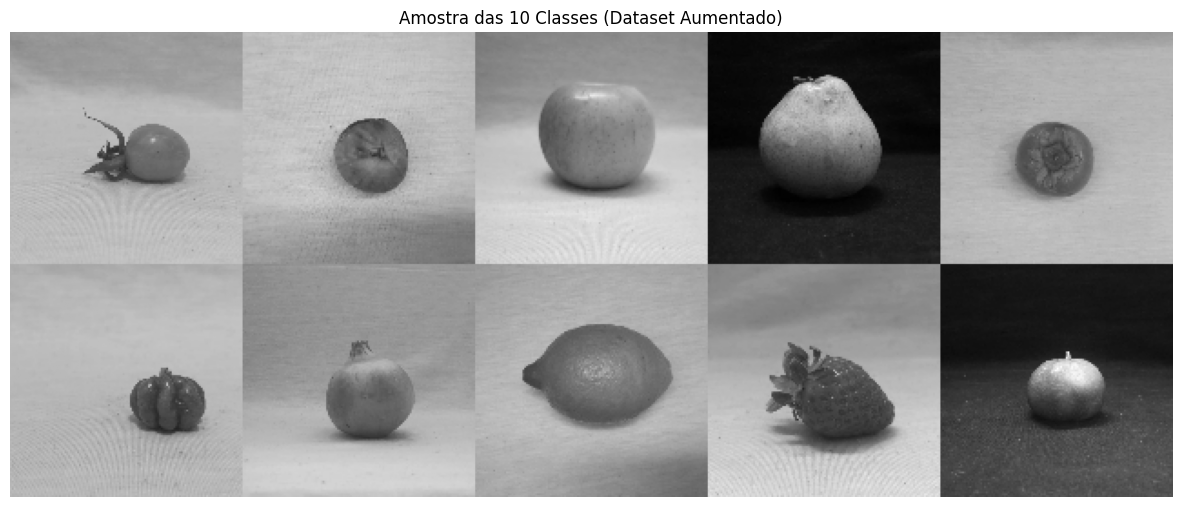

In [ ]:
import os
import cv2
import numpy as np
from matplotlib import pyplot as plt

# Caminho onde o repo foi clonado
repo_path = 'Projeto'

# Classes baseadas no seu arquivo Tabela.txt
classes = ["00", "01", "02", "03", "04", "05", "06", "07", "08", "09"]

# Criar a pasta de destino para o dataset aumentado
output_dir = 'augmented_dataset'
os.makedirs(output_dir, exist_ok=True)
def transform_log(image):
    # Evitar log de zero adicionando 1, e normalizar para 0-255
    c = 255 / np.log(1 + np.max(image))
    log_image = c * (np.log(image + 1))
    return np.array(log_image, dtype=np.uint8)

def transform_exp(image, gamma=0.5):
    # Normalização para intervalo [0, 1] antes da potência
    exp_image = np.array(255 * (image / 255) ** gamma, dtype=np.uint8)
    return exp_image

def apply_blur(image):
    # Filtro de média com kernel 5x5 conforme roteiro
    return cv2.blur(image, (5, 5))
    for cls in classes:
    class_path = os.path.join(repo_path, cls)
    save_class_path = os.path.join(output_dir, cls)
    os.makedirs(save_class_path, exist_ok=True)

    if os.path.exists(class_path):
        for filename in os.listdir(class_path):
            if filename.lower().endswith('.png'):
                img_full_path = os.path.join(class_path, filename)
                img = cv2.imread(img_full_path)

                if img is not None:
                    # Gerar versões
                    img_log = transform_log(img)
                    img_exp = transform_exp(img)
                    img_blur = apply_blur(img)

                    # Salvar com sufixos identificadores
                    base_name = filename.split('.')[0]
                    cv2.imwrite(os.path.join(save_class_path, f"{base_name}_orig.png"), img)
                    cv2.imwrite(os.path.join(save_class_path, f"{base_name}_log.png"), img_log)
                    cv2.imwrite(os.path.join(save_class_path, f"{base_name}_exp.png"), img_exp)
                    cv2.imwrite(os.path.join(save_class_path, f"{base_name}_blur.png"), img_blur)

print("Processamento concluído: augmented_dataset criado!")
from skimage.util import montage

montage_images = []
for cls in classes:
    folder = os.path.join(output_dir, cls)
    # Pega uma imagem qualquer da pasta para representar a classe
    sample_file = os.listdir(folder)[0]
    sample_img = cv2.imread(os.path.join(folder, sample_file), 0) # Escala de cinza
    sample_img = cv2.resize(sample_img, (100, 100))
    montage_images.append(sample_img)

# Criar grade 2x5 (para as 10 classes)
grid = montage(np.array(montage_images), grid_shape=(2, 5))

plt.figure(figsize=(12, 6))
plt.imshow(grid, cmap='gray')
plt.title("Amostra das 10 Classes - Dataset Aumentado")
plt.axis('off')
plt.show()

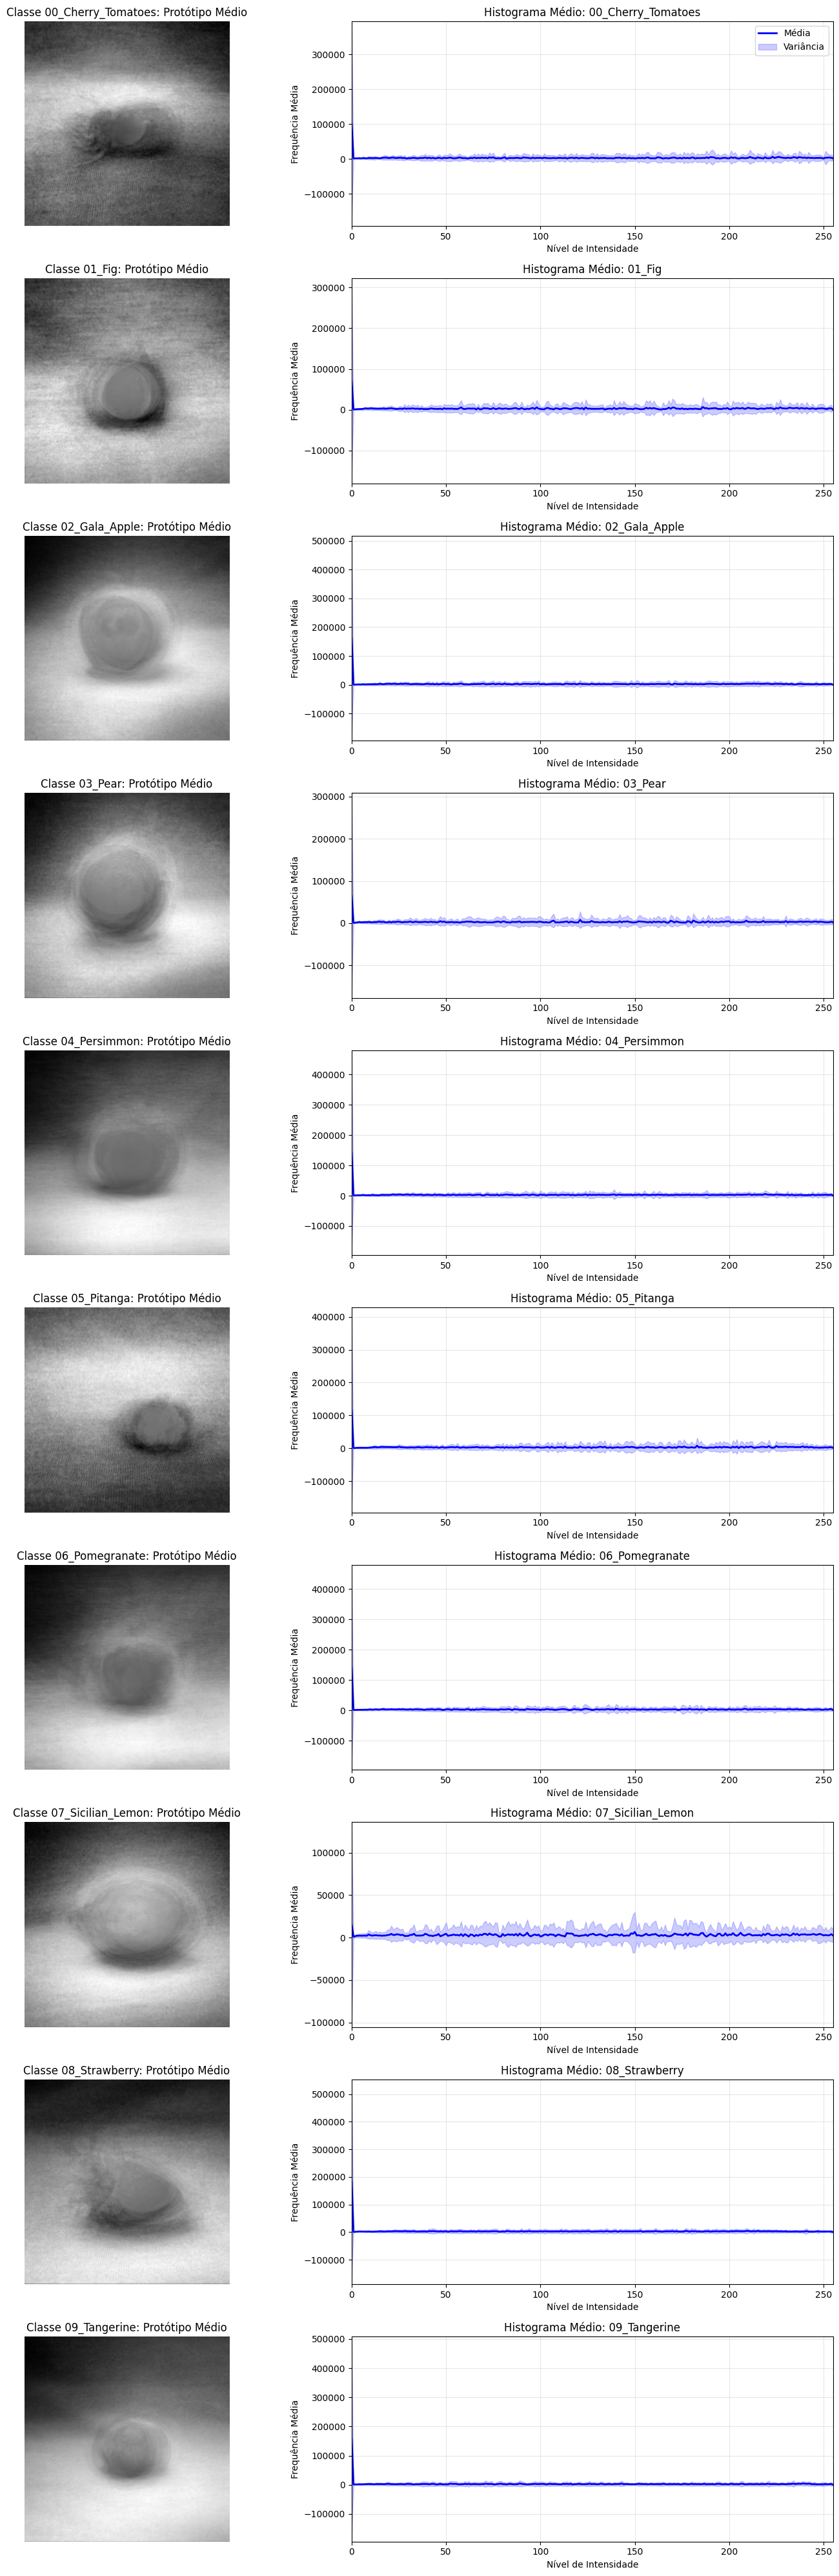

Relatório de Estatísticas Gerado.
Classe 00_Cherry_Tomatoes: Pixels processados para média.
Classe 01_Fig: Pixels processados para média.
Classe 02_Gala_Apple: Pixels processados para média.
Classe 03_Pear: Pixels processados para média.
Classe 04_Persimmon: Pixels processados para média.
Classe 05_Pitanga: Pixels processados para média.
Classe 06_Pomegranate: Pixels processados para média.
Classe 07_Sicilian_Lemon: Pixels processados para média.
Classe 08_Strawberry: Pixels processados para média.
Classe 09_Tangerine: Pixels processados para média.


In [ ]:
import os
import cv2
import numpy as np
from matplotlib import pyplot as plt

# --- 1. CONFIGURAÇÕES ---
# Assumindo que o dicionário 'stats' já foi populado no passo anterior
# Se não, certifique-se de rodar o bloco de cálculo antes deste.

classes = sorted(stats.keys())
n_classes = len(classes)

# Criar uma figura grande para acomodar as 10 classes
# Teremos 10 linhas e 2 colunas (Protótipo | Histograma)
fig, axes = plt.subplots(n_classes, 2, figsize=(15, 4 * n_classes))

for i, class_name in enumerate(classes):
    # --- COLUNA 1: PROTÓTIPO MÉDIO ---
    # Usamos o dado calculado anteriormente no dicionário 'stats'
    proto = stats[class_name]['prototype']
    axes[i, 0].imshow(proto, cmap='gray')
    axes[i, 0].set_title(f"Classe {class_name}: Protótipo Médio", fontsize=12)
    axes[i, 0].axis('off')

    # --- COLUNA 2: HISTOGRAMA MÉDIO ---
    avg_hist = stats[class_name]['avg_hist']
    var_hist = stats[class_name]['var_hist']
    std_hist = np.sqrt(var_hist) # Desvio padrão para a área de sombra

    x = np.arange(256)
    axes[i, 1].plot(x, avg_hist, color='blue', lw=2, label='Média')

    # Preencher a área da variância (sombra) para mostrar a dispersão da classe
    axes[i, 1].fill_between(x,
                            (avg_hist.flatten() - std_hist.flatten()),
                            (avg_hist.flatten() + std_hist.flatten()),
                            color='blue', alpha=0.2, label='Variância')

    axes[i, 1].set_title(f"Histograma Médio: {class_name}", fontsize=12)
    axes[i, 1].set_xlim([0, 255])
    axes[i, 1].set_xlabel("Nível de Intensidade")
    axes[i, 1].set_ylabel("Frequência Média")
    axes[i, 1].grid(True, alpha=0.3)
    if i == 0:
        axes[i, 1].legend()

# Ajustar o layout para as imagens não ficarem sobrepostas
plt.tight_layout()
plt.show()

# --- 2. VERIFICAÇÃO DE DADOS ---
print("Relatório de Estatísticas Gerado.")
for class_name in classes:
    print(f"Classe {class_name}: Pixels processados para média.")

In [21]:
import os
import cv2
import numpy as np
import pandas as pd
from skimage.feature import graycomatrix, graycoprops

# --- CONFIGURAÇÕES ---
input_dir = 'normalized_dataset'
output_csv = 'metadados_atributos.csv'

def get_refined_mask(image_bgr):
    hsv = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2HSV)
    _, s, _ = cv2.split(hsv)
    blur_s = cv2.GaussianBlur(s, (7, 7), 0)
    _, mask = cv2.threshold(blur_s, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
    kernel = np.ones((5,5), np.uint8)
    return cv2.morphologyEx(mask, cv2.MORPH_CLOSE, kernel, iterations=2)

data = []
classes = sorted([d for d in os.listdir(input_dir) if os.path.isdir(os.path.join(input_dir, d))])

for cls in classes:
    class_path = os.path.join(input_dir, cls)
    imagens = [f for f in os.listdir(class_path) if f.lower().endswith('.png')]

    for filename in imagens:
        img = cv2.imread(os.path.join(class_path, filename))
        if img is not None:
            mask = get_refined_mask(img)
            hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)

            # --- NOVO ATRIBUTO: HUE (MATIZ) ---
            # O Hue ignora se a fruta está clara ou escura e foca na "cor pura"
            mean_hsv = cv2.mean(hsv, mask=mask)
            hue_mean = mean_hsv[0]

            # --- ATRIBUTOS DE FORMA MELHORADOS ---
            contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
            if contours:
                cnt = max(contours, key=cv2.contourArea)
                area = cv2.contourArea(cnt)
                perimetro = cv2.arcLength(cnt, True)
                circularidade = (4 * np.pi * area) / (perimetro ** 2) if perimetro > 0 else 0

                # Aspect Ratio (Diferencia Pera de Maçã)
                x, y, w, h = cv2.boundingRect(cnt)
                aspect_ratio = float(w)/h
            else:
                area = circularidade = aspect_ratio = 0

            # --- TEXTURA (GLCM) ---
            gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
            glcm = graycomatrix(gray, distances=[5], angles=[0], levels=256, symmetric=True, normed=True)
            contraste = graycoprops(glcm, 'contrast')[0, 0]
            homogeneidade = graycoprops(glcm, 'homogeneity')[0, 0]

            data.append({
                'label': cls,
                'hue': hue_mean, # Atributo matador para o Morango
                'circularidade': circularidade,
                'aspect_ratio': aspect_ratio,
                'contraste': contraste,
                'homogeneidade': homogeneidade,
                'area': area
            })

df = pd.DataFrame(data)
df.to_csv(output_csv, index=False)
print("Extração concluída com novos atributos (Hue e Aspect Ratio)!")

Extração concluída com novos atributos (Hue e Aspect Ratio)!


Iniciando treinamento com os novos atributos...

ACURÁCIA COM NOVOS ATRIBUTOS: 69.69%

Relatório Detalhado:
                    precision    recall  f1-score   support

00_Cherry_Tomatoes       0.86      0.97      0.91        32
            01_Fig       0.85      0.72      0.78        32
     02_Gala_Apple       0.70      0.59      0.64        32
           03_Pear       0.81      0.69      0.75        32
      04_Persimmon       0.58      0.59      0.58        32
        05_Pitanga       0.89      0.78      0.83        32
    06_Pomegranate       0.74      0.44      0.55        32
 07_Sicilian_Lemon       0.85      0.69      0.76        32
     08_Strawberry       0.37      0.81      0.50        32
      09_Tangerine       0.85      0.69      0.76        32

          accuracy                           0.70       320
         macro avg       0.75      0.70      0.71       320
      weighted avg       0.75      0.70      0.71       320



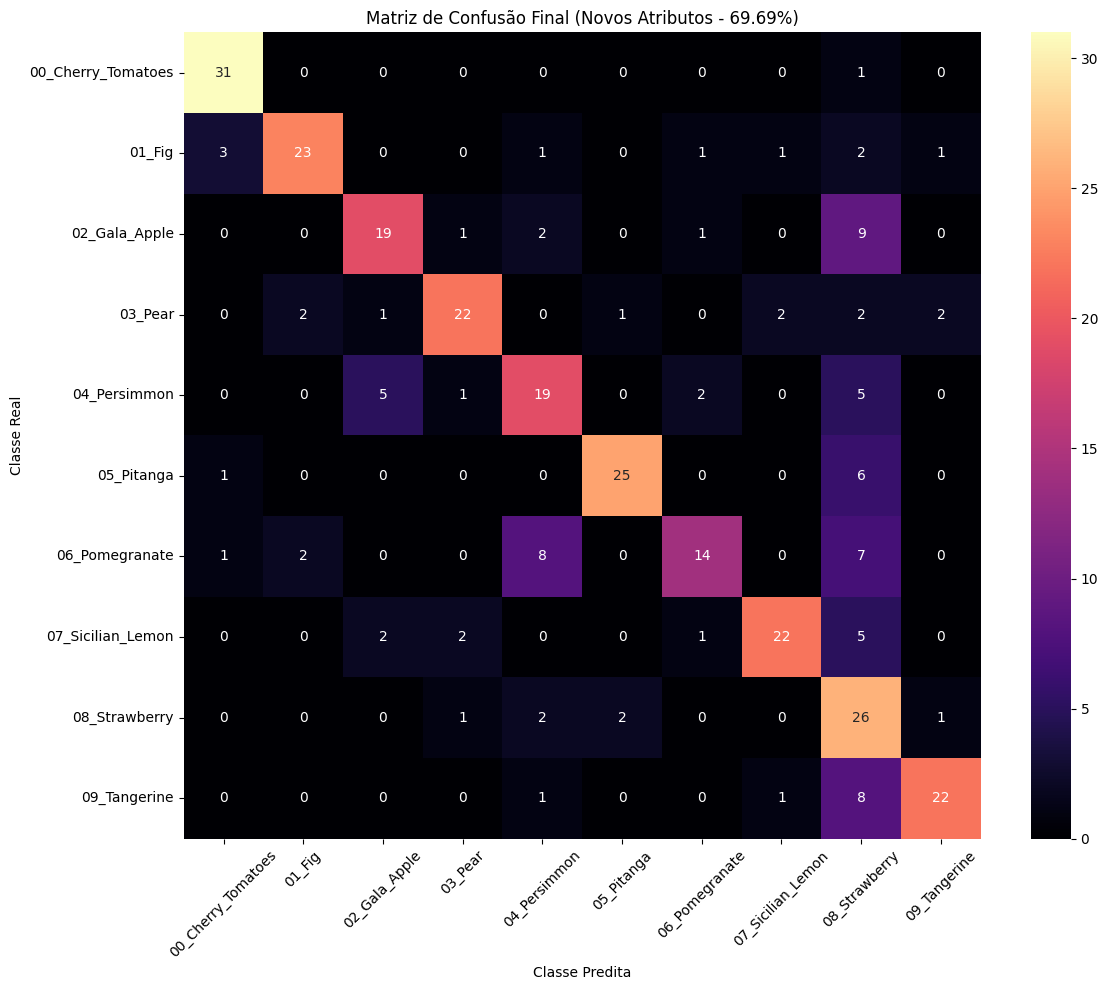

In [23]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# --- 1. CARREGAR E PREPARAR DADOS ---
df = pd.read_csv('metadados_atributos.csv')

# --- CORREÇÃO AQUI: Selecionando as colunas que realmente existem no seu CSV ---
# Agora usamos 'hue', 'aspect_ratio' e 'homogeneidade' em vez de RGB e Energia
X = df[['hue', 'circularidade', 'aspect_ratio', 'contraste', 'homogeneidade', 'area']]
y = df['label']

# --- 2. DIVISÃO TREINO/TESTE ---
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42, stratify=y)

# --- 3. NORMALIZAÇÃO ---
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# --- 4. TUNING DO MODELO (KERNEL RBF) ---
param_grid = {
    'C': [0.1, 1, 10, 100],
    'gamma': [1, 0.1, 0.01, 0.001],
    'kernel': ['rbf']
}

print("Iniciando treinamento com os novos atributos...")
grid = GridSearchCV(SVC(), param_grid, refit=True, verbose=0, cv=5)
grid.fit(X_train_scaled, y_train)

# --- 5. PREDICÃO E AVALIAÇÃO ---
y_pred = grid.predict(X_test_scaled)
accuracy = accuracy_score(y_test, y_pred)

print("\n" + "="*30)
print(f"ACURÁCIA COM NOVOS ATRIBUTOS: {accuracy*100:.2f}%")
print("="*30)

print("\nRelatório Detalhado:")
print(classification_report(y_test, y_pred))

# --- 6. MATRIZ DE CONFUSÃO ---
plt.figure(figsize=(12, 10))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='magma',
            xticklabels=sorted(y.unique()),
            yticklabels=sorted(y.unique()))

plt.title(f'Matriz de Confusão Final (Novos Atributos - {accuracy*100:.2f}%)')
plt.ylabel('Classe Real')
plt.xlabel('Classe Predita')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Found 1280 images belonging to 10 classes.
Found 320 images belonging to 10 classes.
Iniciando treinamento da Rede Neural...


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/15
40/40 ━━━━━━━━━━━━━━━━━━━━ 77s 2s/step - accuracy: 0.1688 - loss: 2.2201 - val_accuracy: 0.4406 - val_loss: 1.7103
Epoch 2/15
40/40 ━━━━━━━━━━━━━━━━━━━━ 67s 2s/step - accuracy: 0.4609 - loss: 1.5568 - val_accuracy: 0.6594 - val_loss: 1.1485
Epoch 3/15
40/40 ━━━━━━━━━━━━━━━━━━━━ 64s 2s/step - accuracy: 0.6273 - loss: 1.0839 - val_accuracy: 0.6687 - val_loss: 1.0484
Epoch 4/15
40/40 ━━━━━━━━━━━━━━━━━━━━ 64s 2s/step - accuracy: 0.6719 - loss: 0.9137 - val_accuracy: 0.7281 - val_loss: 0.8548
Epoch 5/15
40/40 ━━━━━━━━━━━━━━━━━━━━ 64s 2s/step - accuracy: 0.7391 - loss: 0.7438 - val_accuracy: 0.7469 - val_loss: 0.7443
Epoch 6/15
40/40 ━━━━━━━━━━━━━━━━━━━━ 63s 2s/step - accuracy: 0.7195 - loss: 0.7577 - val_accuracy: 0.7594 - val_loss: 0.7289
Epoch 7/15
40/40 ━━━━━━━━━━━━━━━━━━━━ 64s 2s/step - accuracy: 0.7445 - loss: 0.6705 - val_accuracy: 0.7688 - val_loss: 0.7640
Epoch 8/15
40/40 ━━━━━━━━━━━━━━━━━━━━ 65s 2s/step - accuracy: 0.7742 - loss: 0.5820 - val_accuracy: 0.7688 - val_loss:

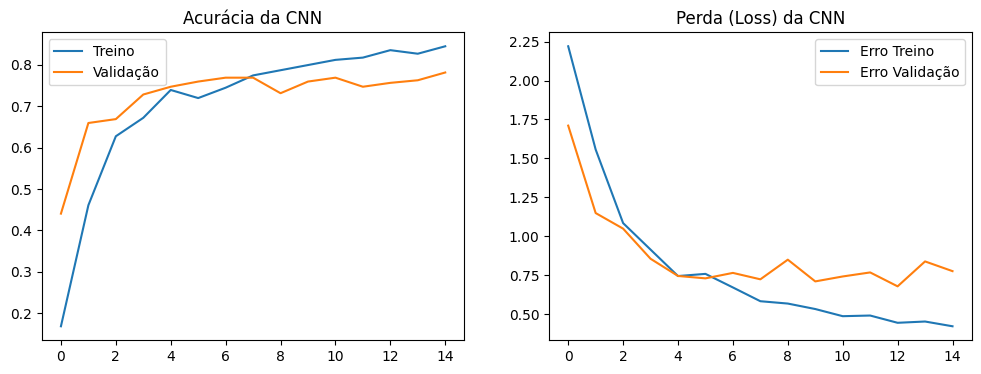

In [24]:
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import matplotlib.pyplot as plt

# --- 1. PREPARAÇÃO DOS DADOS (Etapa 6.2) ---
# O ImageDataGenerator já normaliza e divide os dados automaticamente
datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2
)

train_generator = datagen.flow_from_directory(
    'augmented_dataset',
    target_size=(128, 128), # Redimensiona para um tamanho padrão
    batch_size=32,
    class_mode='categorical',
    subset='training'
)

val_generator = datagen.flow_from_directory(
    'augmented_dataset',
    target_size=(128, 128),
    batch_size=32,
    class_mode='categorical',
    subset='validation'
)

# --- 2. CONSTRUÇÃO DA ARQUITETURA CNN ---
model = models.Sequential([
    # Primeira camada de convolução (extrai bordas/cores)
    layers.Conv2D(32, (3, 3), activation='relu', input_shape=(128, 128, 3)),
    layers.MaxPooling2D((2, 2)),

    # Segunda camada (extrai texturas complexas)
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),

    # Terceira camada
    layers.Conv2D(128, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),

    # Transformar em vetor e classificar
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5), # Evita overfitting
    layers.Dense(10, activation='softmax') # 10 classes de frutas
])

model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

# --- 3. TREINAMENTO ---
print("Iniciando treinamento da Rede Neural...")
history = model.fit(
    train_generator,
    epochs=15, # 15 épocas costumam ser suficientes para este dataset
    validation_data=val_generator
)

# --- 4. EXIBIÇÃO DOS RESULTADOS ---
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Treino')
plt.plot(history.history['val_accuracy'], label='Validação')
plt.title('Acurácia da CNN')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Erro Treino')
plt.plot(history.history['val_loss'], label='Erro Validação')
plt.title('Perda (Loss) da CNN')
plt.legend()
plt.show()